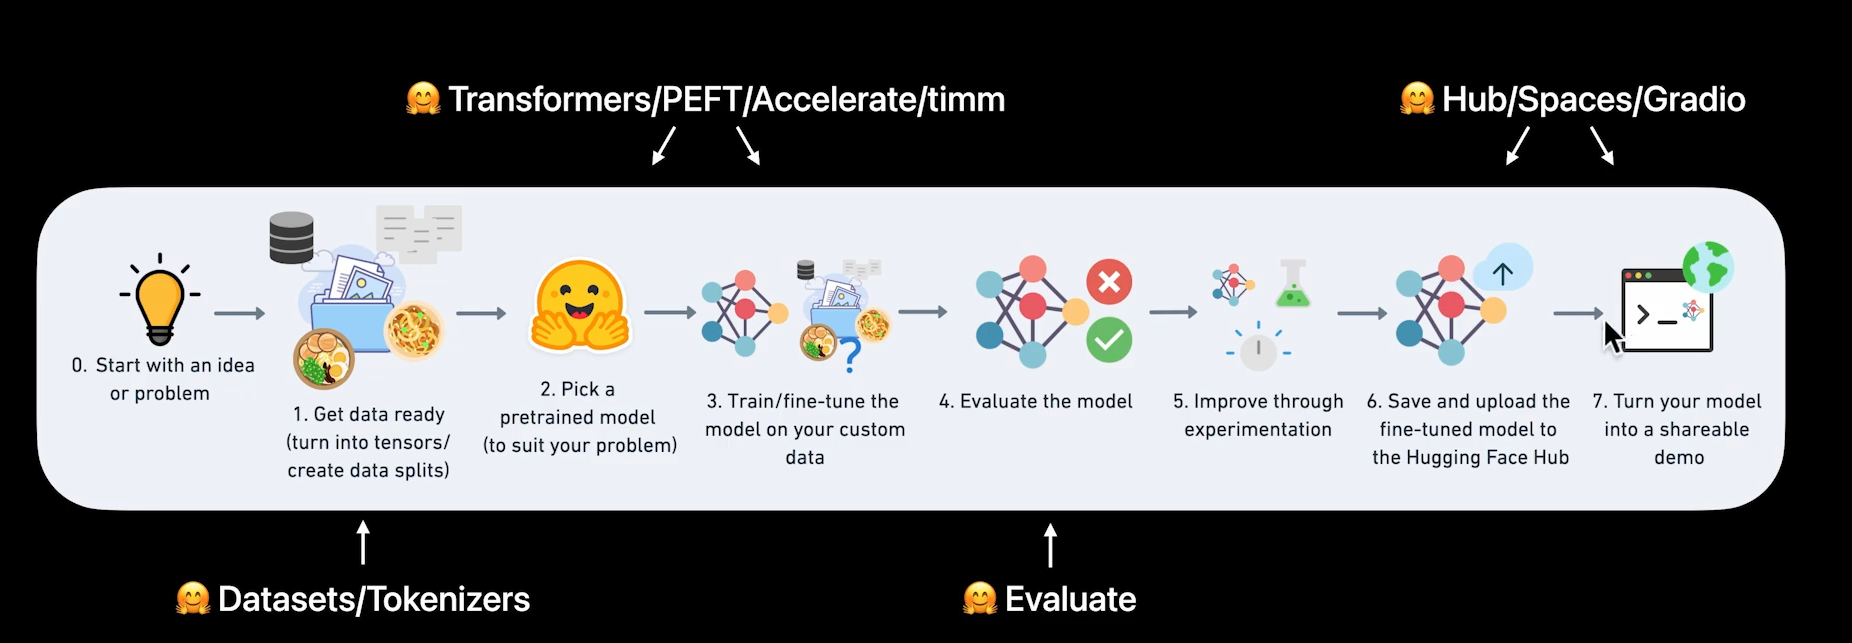

##Importing necessary libraries

In [ ]:
try:
  import datasets
  import gradio as gr
  import torchmetrics
  import pycocotools
except ModuleNotFoundError:

  # If a module isn't found, install it
  !pip install -U datasets gradio # -U stands for "upgrade" so we'll get the latest version by default
  !pip install -U torchmetrics[detection]

  import datasets
  import gradio as gr

  # Required for evalation
  import torchmetrics
  import pycocotools # make sure to have this for torchmetrics

import random

import numpy as np

import torch
import transformers

# Check versions (as long as you've got the following versions or higher, you should be good)
print(f"Using transformers version: {transformers.__version__}")
print(f"Using datasets version: {datasets.__version__}")
print(f"Using torch version: {torch.__version__}")
print(f"Using torchmetrics version: {torchmetrics.__version__}")

##Loading the dataset

In [ ]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("mrdbourke/trashify_manual_labelled_images")

In [ ]:
ds

In [ ]:
ds['train'][88]

In [ ]:
ds['train'][88]['image']


## Explore our dataset

Rule of thumb:
* When downloading a new dataset, view 100 random samples (at least)
* Explore what each of the fields mean (whenever possible)

In [ ]:
from pprint import pprint

pprint(ds['train'].features)

In [ ]:
# Get the categories from the dataset

categories = ds['train'].features['annotations']['category_id'].feature.names



In [ ]:
categories

In [ ]:
id2label = {index: x for index, x in enumerate(categories, start=0)}
label2id = {v: k for k, v in id2label.items()}

In [ ]:
id2label

In [ ]:
label2id

##Creating a color palette



In [ ]:
# Make color dictionary --> mapping from class name to RGB color

color_palette = {
    "bin": (0, 0, 224), # blue
    "not_bin": (255, 80, 80), # red

    "hand": (148, 0, 211), # purple
    "not_hand": (255, 80, 80), # red

    "trash": (0, 255, 0), # Green
    "not_trash": (255, 80, 80), # Red

    "trash_arm": (255, 140, 0) # orange
}

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Normalize RGB values to 0-1 range

def normalize_rgb (rgb_tuple):
  return tuple(x/255.0 for x in rgb_tuple)



# turn the colors into normalized RGB values for matplotlib

colors_and_labels_rgb = [(key, normalize_rgb(value)) for key, value in color_palette.items()]

colors_and_labels_rgb


# Create a figure

fig, ax = plt.subplots(nrows=1, ncols=7, figsize=(8, 1))

# Plot each color on a square

for idx, (label, color) in enumerate(colors_and_labels_rgb):
  ax[idx].add_patch(plt.Rectangle(xy=(0,0),
                                  width=1,
                                  height=1,
                                  facecolor=color))
  ax[idx].set_title(label)
  ax[idx].axis("off")

plt.tight_layout()
plt.show()

##Plotting a single image and visualize the boxes


### Creating a helper functions to view the images and boxes

In [ ]:
from PIL import Image
import PIL

def half_image(image: PIL.Image) -> PIL.Image:
  '''
  resize a given input image by half and returns the samaller version.
  '''

  return image.resize(size=(image.size[0] // 2, image.size[1] // 2))

In [ ]:
import numpy as np

def half_boxes(boxes):
  # work with lists of lists
  if isinstance(boxes, list):
    # if boxes are lists of lists, then we have multiple boxes
    for box in boxes:
      if isinstance(box, list):
        return [[coord // 2 for coord in box] for box in boxes]
      else:
        return [coord // 2 for coord in boxes]


 # work with numpy arrays
  if isinstance(boxes, np.ndarray):
    return (boxes // 2)

  # work with tensors
  if isinstance(boxes, torch.Tensor):
    return (boxes // 2)

In [ ]:
half_image(ds['train'][77]['image'])

In [ ]:
half_boxes(boxes=[[100, 100,100]])

In [ ]:
# Testing the both functions

sample_image = ds['train'][7]['image']
half_sample_image = half_image(sample_image)

print(f"[INFO] The original image size: {sample_image.size} | The new image size: {half_sample_image.size}")


example_boxes_list = [[200, 200, 200, 200],
                      [300, 300, 300, 300]]

example_boxes_list_half = half_boxes(boxes=example_boxes_list)

example_boxes_torch = torch.tensor([[100, 100, 100, 100],
                                    [200, 200, 200, 200]])

example_boxes_torch_half = half_boxes(boxes=example_boxes_torch)

print(f"[INFO] Original boxes list:\n{example_boxes_list}\nHalved:\n{example_boxes_list_half}")
print()
print(f"[INFO] Torch boxes list:\n{example_boxes_torch}\nHalved:\n{example_boxes_torch_half}")



### Understanding Bounding Box Formats

In object detection, bounding boxes are often represented in different formats. `XYWH` and `XYXY` are two common ways to define the coordinates of a box:

*   **`XYWH` (X-coordinate, Y-coordinate, Width, Height)**: This format specifies the top-left corner of the bounding box (`X`, `Y`) along with its `Width` and `Height`.
*   **`XYXY` (X-min, Y-min, X-max, Y-max)**: This format specifies the minimum X and Y coordinates (`X-min`, `Y-min`) for the top-left corner, and the maximum X and Y coordinates (`X-max`, `Y-max`) for the bottom-right corner of the bounding box.

Converting from `XYWH` to `XYXY` means changing the representation of a bounding box from (top-left X, top-left Y, width, height) to (top-left X, top-left Y, bottom-right X, bottom-right Y). This conversion is often necessary because different object detection models or libraries expect one format over the other. For instance, `torchvision` often uses the `XYXY` format for plotting bounding boxes.

### Plotting a single image with bounding boxes step by step

Working towards 100 samples.

1. Select a random sample from the `dataset` .
2. Get the image from `"image"`.
  * Optionally: half the image/boxes.
3. Turn the box coordinates into a `torch.tensor` (use `torchvision` to
help plot the boxes).
4. Convert box format from `XYWH` to `XYXY` using `torchvision.ops.box_convert`(this is because `torchvision.utils.draw_bounding_boxes` requires
`XYXY` format).
5. Get a list of label names from the `category_id` field so we plot the class
names of the particular box on the rectangle.
6. Draw the target boxes onto the target image:
* Turn our PIL image into tnesor with `torchvision.transformers.functional.pil_to_tensor`.
* Once got a tensor, can draw boxes with `torchvision.utils.draw_bounding_boxes`.
* Turn the image and the drawn boxes from tensor back to `PIL` image:
`torchvision.transformers. functional.tensor_to_pil_image`.

In [ ]:
ds['train'][0]['annotations']['bbox'][0] # are in the XYWH

In [ ]:
import random
import torch
from torchvision.ops import box_convert
from torchvision.utils import draw_bounding_boxes

from torchvision.transforms.functional import pil_to_tensor, to_pil_image

random_idx = random.randint(0, len(ds['train']))
print(f"[INFO] Showing training sample from index: {random_idx}")
random_sample = ds['train'][random_idx]
randdom_image = random_sample['image']
random_boxes = random_sample['annotations']['bbox']

half_random_sample_image = half_image(randdom_image)
half_random_sample_boxes = half_boxes(boxes=random_boxes)

boxes_xywh = torch.tensor(half_random_sample_boxes)
print(f"[INFO] Boxes in XYWH format: {boxes_xywh}")
boxes_xyxy = box_convert(boxes=boxes_xywh,
                         in_fmt='xywh',
                         out_fmt='xyxy')
print(f"[INFO] Boxes in XYXY format: {boxes_xyxy}")

random_sample_label_names = [id2label[x] for x in random_sample['annotations']['category_id']]
print(f"[INFO] Random sample labels: {random_sample_label_names}")
random_sample_colors = [color_palette[class_name] for class_name in random_sample_label_names]
print(f"[INFO] Random sample colors: {random_sample_colors}")



output_image = to_pil_image(
    pic=draw_bounding_boxes(
        image=pil_to_tensor(pic=half_random_sample_image),
        boxes=boxes_xyxy,
        labels=random_sample_label_names,
        colors=random_sample_colors,
        width=3,
        label_colors=random_sample_colors


    )
)
output_image

##Different bounding box formats

One of the most important and sometimes confusing things you'll find in object detection projects is the format of the bounding boxes.
The first question you should often ask is:

**What format are my bounding boxes in?**

Are they in XYXY or XYWH ?

And are the coordinates absolute or normalized?

>**Note:** To learn more on the different formats and how to plot them, read the following guide: https://www.learnml.io/posts/a-guide-to-bounding-box-formats/


Why do we do this?

1. Wrong box format = wrong visualizations
2. Wrong box format = poor model training

##Creating/getting and Object detection model

1. **Build it ourselves from scratch** - construct the model layer by layer
2. **Get an existing model** - use an existing model that has been proven to work on a
similar problem and then customize it to our own use case (transfer learning)
  * Note: This is typically the most common use case when starting with Hugging Face


Places to get OD models:

- torchvision - https://docs.pytorch.org/vision/stable/models.html#object-detection-instance-segmentation-and-person-keypoint-detection
- Hugging Face models - https://huggingface.co/models?pipeline_tag=object-detection&sort=trending
- Apache 2.0 object detection models - https://www.learnml.io/posts/apache-object-detection-models/

In [ ]:
id2label

## Creating a function to create our own custom model

We've got a model that has been pre-trained on COCO (80 classes) but we want to customize
our model to work on 7 classes for Trashify.

* Docs to RT-DETRv2 model - https://huggingface.co/docs/transformers/main/en/model_doc/rt_detr_v2#rt-detrv2
* Docs to RT-DETR preprocessor - https://huggingface.co/docs/transformers/en/model_doc/rt_detr#transformers. RTDetrImageProcessor

> **Note:** Hugging Face has the concept of "Auto Model" and "Auto Processor" which will automatically create a model/processor object depending on the input model/processor name.

In [ ]:
from transformers import AutoModelForObjectDetection

# create a function to instantiate our own custom model

MODEL_NAME = "PekingU/rtdetr_v2_r50vd"

def create_model(pretrained_model_name_or_path: str = MODEL_NAME,
                 label2id: dict = label2id,
                 id2label: dict = id2label):

  model = AutoModelForObjectDetection.from_pretrained(
      pretrained_model_name_or_path,
      num_labels=len(label2id),
      id2label=id2label,
      label2id=label2id,
      ignore_mismatched_sizes=True # to ignore size mismatches when loading a pretrained model
  )
  return model



custom_model = create_model()

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"The custom model has {count_parameters(custom_model):,} learnable parameters.")

In [ ]:
half_image(ds['train'][3]['image'])

In [ ]:
from transformers import  RTDetrImageProcessor
image_processor = RTDetrImageProcessor.from_pretrained("PekingU/rtdetr_v2_r50vd")

In [ ]:
custom_inputs = image_processor(images=ds['train'][3]['image'], return_tensors="pt")
custom_inputs

In [ ]:
custom_inputs = image_processor(images=ds['train'][3]['image'], return_tensors="pt")

with torch.no_grad():
  custom_outputs = custom_model(**custom_inputs) # same as "pixel_values = custom_inputs["pixel_values"]"



results = image_processor.post_process_object_detection(custom_outputs, target_sizes=torch.tensor([(half_image(ds['train'][3]['image']).height, half_image(ds['train'][3]['image']).width)]), threshold=0.5)

label_names=[]
for result in results:
     for score, label_id, box in zip(result["scores"], result["labels"], result["boxes"]):
         score, label = score.item(), label_id.item()
         box = [round(i, 2) for i in box.tolist()]
         print(f"{custom_model.config.id2label[label]}: {score:.2f} {box}")

         label_names.append(custom_model.config.id2label[label])

In [ ]:
output_image = to_pil_image(
    pic=draw_bounding_boxes(
        image=pil_to_tensor(pic=half_image(ds['train'][3]['image'])),
        boxes=results[0]['boxes'],
        labels=label_names,
        #colors=random_sample_colors,
        width=3,
        #label_colors=random_sample_colors


    )
)
output_image

In [ ]:
# loading the model preprocessor

from transformers import AutoImageProcessor

MODEL_NAME = 'PekingU/rtdetr_v2_r50vd'

image_processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

image_processor

###Notice the format of our data:


* Data format: pixel values will be: colour_channels, height, width --> CHW
* Some libraries use the format: HWC (TensorFlow)
* `"format": "coco_detection"`

- ```
  "size":{
    "height": 640,
    "width": 640
  }

In [ ]:
IMAGE_SIZE = 640


image_processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME,
    use_fast=True,
    format='coco_detection',
    do_convert_annotation=True,
    size={
        'shortest_edge': IMAGE_SIZE,
        'longest_edge': IMAGE_SIZE
    },
    return_segmentation_mask=False,
    do_pad=True
)

In [ ]:
image_processor

In [ ]:
random_sample['image']

##Preprocessing an annotation


> Note: the data need to be preprocessed/prepared so that it does not give us poor results.

we have:

- `category_id` = `id2label`

the current format:

```
{'file_name': ['eea91c2f-5284-4eac-9103-8a3296fa315c.jpeg',
  'eea91c2f-5284-4eac-9103-8a3296fa315c.jpeg',
  'eea91c2f-5284-4eac-9103-8a3296fa315c.jpeg'],
 'image_id': [920, 920, 920],
 'category_id': [5, 1, 0],
 'bbox': [[199.1999969482422,
   616.7000122070312,
   344.70001220703125,
   333.1000061035156],
  [458.79998779296875, 722.7000122070312, 248.6999969482422, 236.5],
  [310.1000061035156, 298.0, 285.29998779296875, 450.29998779296875]],
 'iscrowd': [0, 0, 0],
 'area': [114819.5703125, 58817.55078125, 128470.59375]}
 ```

but the model/preprocessor expect the COCO format.

we want this format:
```
annotation{
  "id": int,
  "image_id": int,
  "category_id": int,
  "segmentation": RLE or [polygon],
  "area": float,
  "bbox": [x,y,width,height],
  "iscrowd": 0 or 1,
  }

  categories[{
    "id": int,
    "name": str,
    "supercategory": str,
  }]
```

In [ ]:
random_annotation = random_sample['annotations']
random_annotation

In [ ]:
id2label

##Creating dataclasses to represent the COCO bounding box format


>Remember: dataclasses are a great tool to store a specific structure of data

**doc:** https://docs.python.org/3/library/dataclasses.html


COCO want one dictionary per annotation.

In [ ]:
from dataclasses import dataclass, asdict
from typing import List, Tuple

@dataclass
class SingleCOCOAnnotation:
  image_id: int
  category_id: int
  bbox: List[float]
  area: float
  iscrowd: int = 0


  def __post_init__(self):
    if len(self.bbox) != 4:
      raise VlaueError (f"bbox must contain 4 values, current length: {len(self.bbox)}")



@dataclass
class ImageCOCOAnnotation:
  image_id: int
  annotations: List[SingleCOCOAnnotation]

##Creating a function to format our annotations as COCO format


1. Take in the attribute of a single sample ( in our format )
2. convert it to COCO format using our dataclasses above
3. Return a single sample of our data in COCO format

In [ ]:
def format_image_annotation_as_coco(
    image_id=int,
    categories=List[int],
    areas=List[float],
    bboxes = List[Tuple[float,float,float,float]]
):


  coco_format_annotations = [
      asdict(SingleCOCOAnnotation(
          image_id = image_id,
          category_id = category,
          bbox = list(bbox),
          area = area

      ))
      for category, area, bbox in zip(categories, areas, bboxes)
  ]


  return asdict(ImageCOCOAnnotation(image_id=image_id,
                                    annotations = coco_format_annotations))

In [ ]:
random_sample = ds['train'][77]
random_sample

In [ ]:
random_sample_image_id = random_sample['image_id']
random_sample_categories = random_sample['annotations']['category_id']
random_sample_areas = random_sample['annotations']['area']
random_sample_bboxes = random_sample['annotations']['bbox']

In [ ]:
format_image_annotation_as_coco(random_sample_image_id, random_sample_categories, random_sample_areas, random_sample_bboxes)

In [ ]:
random_sample_preprocessed = image_processor(images=random_sample['image'],
                                             annotations=format_image_annotation_as_coco(random_sample_image_id, random_sample_categories, random_sample_areas, random_sample_bboxes),
                                             do_convert_annotations=True)

In [ ]:
random_sample_preprocessed.labels

In [ ]:
pprint(random_sample_preprocessed.labels[0])

##[INFO]




* `boxes` - Our previous boxes were in **XYWH** absolute format, now they are in **CXCYWH** normalized format, this can
be seen in the `do_convert_annotations` parameter in the [RTDetrImageProcessor documentation](https://huggingface.co/docs/transformers/en/model_doc/rt_detr#transformers.RTDetrImageProcessor)
* `area` - the area values of our bounding boxes
* `class_labels` - the labels our each of our boxes (see `id2label`)
* `image_id` - the global image ID for a given sample
* `orig_size` - the original size of our input image in `(height, width)` format
* `size` - the converted size out of preprocess in `(height, width)` format

##Next is the Post processing a single output

check the doc about the function --> [post_process_object_detection](https://huggingface.co/docs/transformers/en/model_doc/rt_detr#transformers.RTDetrImageProcessor)

---

`post_process_object_detection` is like the final cleanup crew. It takes the model's raw ideas about where objects are and what they are, filters out the less confident guesses, scales the bounding boxes back to their original image size, and presents everything in a neat, easy-to-understand format (`scores`, `labels`, `boxes` in `XYXY` format) that you can then use to visualize the results or make decisions.





In [ ]:
model_raw_output= custom_model(random_sample_preprocessed['pixel_values'])

In [ ]:
model_raw_output['logits'].shape

In [ ]:
random_sample_preprocessed['labels'][0]['orig_size'].unsqueeze(0).shape

In [ ]:
model_raw_output.keys()

In [ ]:
THRESHOLD = 0.4

random_sample_outputs_post_processed = image_processor.post_process_object_detection(
    outputs = model_raw_output,
    threshold = THRESHOLD,
    target_sizes = random_sample_preprocessed['labels'][0]['orig_size'].unsqueeze(0)
)

random_sample_outputs_post_processed

In [ ]:

help(image_processor.post_process_object_detection)

In [ ]:
len(random_sample_outputs_post_processed[0]['scores'])

In [ ]:

label_names=[]
random_sample_colors=[]
for result in random_sample_outputs_post_processed:
     for score, label_id, box in zip(result["scores"], result["labels"], result["boxes"]):
         score, label = score.item(), label_id.item()
         box = [round(i, 2) for i in box.tolist()]
         print(f"{custom_model.config.id2label[label]}: {score:.2f} {box}")

         random_sample_colors.append(color_palette[custom_model.config.id2label[label]])

         label_names.append(custom_model.config.id2label[label])

In [ ]:
output_image = to_pil_image(
    pic=draw_bounding_boxes(
        image=pil_to_tensor(pic=half_image(random_sample['image'])),
        boxes=half_boxes(random_sample_outputs_post_processed[0]['boxes']),
        labels=label_names,
        colors=random_sample_colors,
        width=3,
        label_colors=random_sample_colors


    )
)
output_image

##Preparing data at scale

1. split the data into Training, validation and testing
2. Preprocess many samples at one time
3. Collate the samples into batches

In [ ]:
ds

In [ ]:
dataset_split = ds['train'].train_test_split(test_size=0.3, seed=42)

In [ ]:
dataset_split

In [ ]:
dataset_test_val_split = dataset_split['test'].train_test_split(test_size=0.6, seed=42)

In [ ]:
dataset_test_val_split

In [ ]:
ds['train'] = dataset_split['train']
ds['validation'] = dataset_test_val_split['train']
ds['test'] = dataset_test_val_split['test']

ds

##Now: writing a function for preprocessing multiple samples at a time


according to the function [preprocess](https://huggingface.co/docs/transformers/model_doc/rt_detr#transformers.RTDetrImageProcessorFast.preprocess) we need:

- A list of images
- a list of annotation in COCO format, our function was `format_image_annotation_as_coco`



In [ ]:
from transformers import  RTDetrImageProcessor

help(RTDetrImageProcessor.preprocess)

In [ ]:
ds['train'][67]

In [ ]:
ds['train'][:3]

In [ ]:
ds['train'][:3]['image']



Something to note: Hugging Face Datasets is built on Apache Arrow, this database is column-like in style rather than
row-like.

* See docs for Datasets + Apache Arrow: https://huggingface.co/docs/datasets/en/about_arrow

We need our function to turn a list of given samples from our dataset into the format our `preprocess' method wants.

Why preprocess a bunch of samples at a time?

Generally, it's more efficient to preprocess or perform the same operation on a group of samples at the same time
rather than just one by one.

Especially for GPU computing, you want to spend as little time as possible transferring data and more time using GPU
compute.

Let's start writing our function:

1. Take in a list of examples (these will be in the raw data format, or our original data format), and
`image_processor` instance and optional `transforms` (we can use these transforms for data augmentation).
2. Create empty lists of `images` and `coco_annotations`.
3. Extract the `image`, `image_id` and `annotations_dict` from our list of input examples.
4. Create lists of annotations attributes such as `bbox`, `category_id` and `area` (these are required for our
`format_image_annotations_as_coco` function).
5. Optionally perform transforms/augmentations on our image + annotations ( **note :** in object detection if you
transform your image, you *must* transform your annotations as well).
6. Convert the annotations into COCO format using the `format_image_annotations_as_coco`.
7. Append the images and COCO formatted annotations to the empty lists created in step 2.
8. Pass the list of images and COCO formatted annotations to the `image_processor.preprocess` method to get the
preprocessed batch of examples.
9. Return the preprocessed batch.

In [ ]:
def preprocess_batch(examples,
                     image_processor,
                     transforms=None):

  images = []
  coco_annotations = []


  for image, image_id, annotations_dict in zip(examples['image'],
                                               examples['image_id'],
                                               examples['annotations']):

    bbox_list = annotations_dict['bbox']
    category_list = annotations_dict['category_id']
    area_list = annotations_dict['area']

    if transforms:
      pass


    coco_format_annotations = format_image_annotation_as_coco(image_id=image_id,
                                                              categories = category_list,
                                                              areas = area_list,
                                                              bboxes= bbox_list)

    images.append(image)
    coco_annotations.append(coco_format_annotations)


  preprocessed_batch = image_processor.preprocess(images= images,
                                                  annotations= coco_annotations,
                                                  return_tensors='pt')

  return preprocessed_batch






In [ ]:
 preprocessed_group_of_samples = preprocess_batch(ds['train'][:3], image_processor=image_processor)

In [ ]:
preprocessed_group_of_samples

In [ ]:
preprocessed_group_of_samples['pixel_values'].shape # this will give us --> [batch size, color channels, height, width]

##Applying the preprocess function to each data split

In [ ]:
ds

In [ ]:
# Create a partial function for preprocessing
from functools import partial

preprocess_batch_partial = partial(preprocess_batch,
                                   image_processor=image_processor,
                                   transforms=None)


preprocess_batch_partial

In [ ]:
# Apply the partial function to our dataset
processed_dataset = ds.copy();

# Apply processing function
processed_dataset["train"] = processed_dataset["train"].with_transform(transform=preprocess_batch_partial)
processed_dataset["validation"] = processed_dataset["validation"].with_transform(transform=preprocess_batch_partial)
processed_dataset["test"] = processed_dataset["test"].with_transform(transform=preprocess_batch_partial)

In [ ]:
processed_dataset['train'][67]

In [ ]:
ds['train'][67]

In [ ]:
# creating a data collator

def data_collate_function(preprocessed_batch):

  collatted_data = {}


  collatted_data['pixel_values'] = torch.stack([sample['pixel_values'] for sample in preprocessed_batch])

  collatted_data['labels'] = [sample['labels'] for sample in preprocessed_batch]

  if 'pixel_mask' in preprocessed_batch[0]:
    collatted_data['pixel_mask'] = torch.stack([sample["pixel_mask"] for sample in preprocessed_batch])

  return collatted_data

In [ ]:
%%time

# Try data_collate_function
example_collated_data_batch = data_collate_function(processed_dataset["train"].select(range(8)))
example_collated_data_batch.keys()

In [ ]:
# Check shapes of batched preprocessed samples
print(f"[INFO] Batch of pixel value shapes: {example_collated_data_batch['pixel_values'].shape}")
print(f"[INFO] Batch of labels: {example_collated_data_batch['labels']}")
if "pixel_mask" in example_collated_data_batch:
    print(f"[INFO] Batch of pixel masks: {example_collated_data_batch['pixel_mask'].shape}")

In [ ]:


#test_model = create_model()



In [ ]:

#example_batch_outputs = test_model(example_collated_data_batch['pixel_values'])
#example_batch_outputs.keys()

In [ ]:
#example_batch_outputs.logits.shape

In [ ]:
#example_batch_outputs.pred_boxes.shape

##Setting up TrainingArguments and a Trainer instance to train our model


To train a model, go through the following steps:

1. Create a fresh instance of our model using the `create_model()` function.
2. Make a directory for saving our trained models to.
3. Define our model's hyperparameters using `transformers.TrainingArguments`, we'll take many of these settings from the
assosciated research papers that introduced our model.
[research paper 1](https://arxiv.org/abs/2407.17140),
[research paper 2](https://arxiv.org/abs/2304.08069).
4. Optional: Create a custom instance of `transformers.Trainer` to use a custom optimizer with different learning rates for different
parameters (similar to the research papers).
5. Create an evaluation function we can pass to our `transformers.Trainer`  instance as the compute_metrics parameter to
evaluate our model.
6. Create an instance of `transformers.Trainer` and pass it our training arguments from 2 as well as our preprocessed data.
7. Call **`transformers.Trainer.train()`** to train the model from 1 on our own data.
8. Plot our model's loss curves to see how it performed throughout training (ideally our model's loss goes down and its evaluation
metric goes up).

In [ ]:
# 1. Create a fresh instance of our model using the create_model() function.

model = create_model()

In [ ]:
# 2. Make a directory for saving our trained models to.

from pathlib import Path

models_dir = Path('models')
models_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
# 3. setup TraningArguments using transformers.TrainingArguments

from transformers import TrainingArguments

# Hardware dependent hyperparameters

BATCH_SIZE = 8
DATALOADER_NUM_WORKERS = 2 # check: you may have to lower this to os.cpu_count()

# Set number of epochs to how many laps you'd like to do over the data
NUM_EPOCHS = 10

# Setup hyperameters for training from the DETR paper(s)
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 0.1
WARMUP_RATIO = 0.05 # learning rate warmup from 0 to learning_rate as a ratio of total steps (e.g. 0.05 = 5% of total steps)

# Create directory to save models to
OUTPUT_DIR = Path(models_dir, "rt_detrv2_finetuned_trashify_box_detector_v1")
print(f"[INFO] Saving model to: {OUTPUT_DIR}")

# Create TrainingArguments to pass to Trainer
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=MAX_GRAD_NORM,
    num_train_epochs=NUM_EPOCHS,
    lr_scheduler_type="linear",
    warmup_ratio=WARMUP_RATIO,
    logging_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    fp16=True, # use mixed precision training
    dataloader_num_workers=DATALOADER_NUM_WORKERS,
    eval_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False, # want to minimize eval_loss (e.g. lower is better)
    report_to="none", # don't save experiments to a third party service
    push_to_hub=False,
    eval_do_concat_batches=False, # this defaults to True but we'll set it to False for our evaluation function
    # save_safetensors=False # turn this off to prevent potential checkpoint issues
)

In [ ]:
MODEL_NAME

##Optional: Setting up an optimizer for multiple learning rates

In [ ]:
from transformers import Trainer


backbone_params = []
other_params = []


for name, param in model.model.named_parameters():
  if 'backbone' in name:
    backbone_params.append(param)
  else:
    other_params.append(param)


print(f"the number of params in the backbone is: {len(backbone_params)}")
print(f"the number of params in the Non-backbone is: {len(other_params)}")



BACKBONE_LEARNING_RATE = 1e-5
DETECTION_HEAD_LEARNING_RATE = 1e-4

class CustomTrainer(Trainer):
  def create_optimizer(self):

    self.optimizer = torch.optim.AdamW([
        {'params': backbone_params, 'lr': BACKBONE_LEARNING_RATE},
        {'params': other_params, 'lr': DETECTION_HEAD_LEARNING_RATE}
    ],
    weight_decay=WEIGHT_DECAY)
    return self.optimizer

##Creating an evaluation function

Essentially we want an evaluation metric.

Evalution metric = a single number that shows how well your model is doing.

In object detection, one of the main eval metrics is mAP (Mean Average Precision).

We want to measure our model's mAP as it's training ... this way we can see it's performance improving (or not) as we go.

For our evaluation function to calculate mAP, we need:

* A function to go into `compute_metrics` for `Trainer` - https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.Trainer.compute_metrics

* Our function should take in `EvalPrediction` - https://huggingface.co/docs/transformers/v4.53.2/en/internal/trainer_utils#transformers.EvalPrediction

* It should return a dictionary of string to metric (e.g. `{"metric_name": 42 ... }`)
* To calcualte mAP, we'll use torchmetrics - https://lightning.ai/docs/torchmetrics/stable/detection/mean_average_precision.html

* For more about object detection metrics, see Roboflow's guide - https://blog.roboflow.com/object-detection-metrics/

* Also for an introduction to IoU (measures the overlap of a predicted box compared to a ground truth box), see -
https://www.learnml.io/posts/a-gentle-guide-to-intersection-over-union/

So our path is:

* Create to function
* To take model predictions
* Caluclate mAP with torchmetrics
* Return a dictionary of metric name to value
- These will be displayed during training

In [ ]:
from torchvision.ops import box_convert

def convert_bbox_cxcywh_to_xyxy_absolute(boxes,
                                         image_size_target):
    """
    Converts CXCYWH normalized boxes to XYXY absolute boxes.

    The output of our preprocess method puts boxes in CXCYWH format.

    But our evaluation metric torchmetrics.detection.mean_ap.MeanAveragePrecision expects
        boxes in XYXY absolute format.

    Args:
        boxes (torch.Tensor): A tensor of shape (N, 4) where N is the number of boxes and each box is in CXCYWH format.
        image_size_target (tuple): A tuple containing the target image size as (height, width).

    Returns:
        torch.Tensor: A tensor of shape (N, 4) where each box is converted to XYXY absolute format.
    """
    # Convert normalized CXCYWH (output of model) -> absolute XYXY format (required for evaluation)
    boxes = box_convert(boxes=boxes, in_fmt="cxcywh", out_fmt="xyxy")

    # Convert normalized box coordinates to absolute pixel values based on the target size
    image_size_target_height = image_size_target[0]
    image_size_target_width = image_size_target[1]
    boxes = boxes * torch.tensor([image_size_target_width,
                                  image_size_target_height,
                                  image_size_target_width,
                                  image_size_target_height]) # Multiply X coordinates by the width and Y coordinates by the height

    return boxes

In [ ]:
# Create an evaluation function to test our model's performance
import numpy as np
from typing import Optional, Mapping
from transformers import EvalPrediction
from torchmetrics.detection.mean_ap import MeanAveragePrecision


@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor


@torch.no_grad()
def compute_metrics(
    evaluation_results: EvalPrediction,
    image_processor: AutoImageProcessor,
    threshold: float = 0.0,
    id2label: Optional[Mapping[int, str]] = None,
) -> Mapping[str, float]:

    predictions, targets = evaluation_results.predictions, evaluation_results.label_ids


    image_sizes = []
    post_processed_targets = []
    post_processed_predictions = []



    for batch in targets:

        batch_image_sizes = torch.tensor(np.array([x["orig_size"] for x in batch]))
        image_sizes.append(batch_image_sizes)

        for image_target in batch:


            boxes = torch.tensor(image_target["boxes"])
            boxes = convert_bbox_cxcywh_to_xyxy_absolute(boxes=boxes,
                                                         image_size_target=image_target["orig_size"])

            labels = torch.tensor(image_target["class_labels"])


            post_processed_targets.append({"boxes": boxes,
                                           "labels": labels})



    for pred_batch, target_sizes in zip(predictions, image_sizes):


        pred_batch_loss, pred_batch_logits, pred_batch_boxes = pred_batch[0], pred_batch[1], pred_batch[2]

        model_output = ModelOutput(logits=torch.tensor(pred_batch_logits),
                                   pred_boxes=torch.tensor(pred_batch_boxes))


        post_processed_output = image_processor.post_process_object_detection(
                                                    outputs=model_output,
                                                    threshold=threshold,
                                                    target_sizes=target_sizes)


        post_processed_predictions.extend(post_processed_output)


    max_detection_thresholds = [1, 10, 100]
    metric = MeanAveragePrecision(box_format="xyxy",
                                  class_metrics=True,
                                  max_detection_thresholds=max_detection_thresholds)
    metric.warn_on_many_detections = False
    metric.update(post_processed_predictions,
                  post_processed_targets)
    metrics = metric.compute()



    classes = metrics.pop("classes")
    map_per_class = metrics.pop("map_per_class")


    mar_per_class = metrics.pop("mar_100_per_class")


    for class_id, class_map, class_mar in zip(classes, map_per_class, mar_per_class):
        class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
        metrics[f"map_{class_name}"] = class_map


        metrics[f"mar_100_{class_name}"] = class_mar


    metrics = {k: round(v.item(), 4) for k, v in metrics.items()}



    return metrics

eval_compute_metrics_fn = partial(
        compute_metrics,
        image_processor=image_processor,
        threshold=0.0,
        id2label=id2label,
)

In [ ]:
eval_compute_metrics_fn

##Training the model with Trainer

In [ ]:
from transformers import Trainer

model_v1 = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collate_function,
    train_dataset = processed_dataset['train'],
    eval_dataset = processed_dataset['validation'],
    compute_metrics = eval_compute_metrics_fn
)


model_v1_results = model_v1.train()

In [ ]:
# 7. Plotting our model's loss curves
import matplotlib.pyplot as plt

log_history = model_v1.state.log_history

# Exctract loss values
train_loss = [item["loss"] for item in log_history if "loss" in item]
eval_loss = [item["eval_loss"] for item in log_history if "eval_loss" in item]

# Extract mAP values
eval_map = [item["eval_map"] for item in log_history if "eval_map" in item]

# Plot loss curves and mAP
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 7))
ax[0].plot(train_loss, label="Train loss")
ax[0].plot(eval_loss, label="Eval loss")
ax[0].set_title("Loss Curves (lower is better)")
ax[0].set_ylabel("Loss Value")
ax[0].set_xlabel("Epochs")
ax[0].legend()

ax[1].plot(eval_map, label="Eval mAP")
ax[1].set_title("Eval mAP (higher is better)")
ax[1].set_ylabel("mAP (Mean Average Precision)")
ax[1].set_xlabel("Epochs")
ax[1].legend();

In [ ]:
test_metric_outputs = model_v1.evaluate(processed_dataset['test'])
test_metric_outputs

In [ ]:
# # Make predictions with trainer containing trained model
# test_dataset_preds = model_v1.predict(test_dataset=processed_dataset["test"])
# # test_dataset_preds

In [ ]:
# # Predictions come in the same batch size as our training setup
# test_dataset_prediction_outputs = test_dataset_preds.predictions
# test_dataset_label_outputs = test_dataset_preds.label_ids

# print(f"[INFO] Found {len(test_dataset_prediction_outputs)} batches of prediction samples and {len(test_dataset_label_outputs)} batches of labels.")

In [ ]:
# Extract mAP and mAR metrics
test_map_metrics = {key: value for key, value in test_metric_outputs.items() if "map" in key}
test_mar_metrics = {key: value for key, value in test_metric_outputs. items() if "mar" in key}

# Get the labels and values
test_map_labels, test_map_values = test_map_metrics.keys(), test_map_metrics.values()
test_mar_labels, test_mar_values = test_mar_metrics.keys(), test_mar_metrics.values()

test_map_labels = [item. replace("eval", "test") for item in test_map_labels]
test_mar_labels = [item. replace("eval", "test") for item in test_mar_labels]

# Create a subplot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(17, 7), sharey=True)

# Add mAP
ax[0].bar(test_map_labels, test_map_values)
ax[0].set_title("Mean Average Precision (mAP)")
ax[0].set_xlabel("Metric")
ax[0].set_ylabel("Value")
ax[0].tick_params(axis="x", rotation=45)


# Add mar
ax[1].bar(test_mar_labels, test_mar_values)
ax[1].set_title("Mean Average Recall (mar)")
ax[1].set_xlabel("Metric")
ax[1].set_ylabel("Value")
ax[1].tick_params(axis="x", rotation=45)

##Evaluating and visualizing predictions one by one

To visualize our predictions, we're going to:

* Measure the time of a prediction
* Get a random test sample
* Preprocess that random sample
* Make a prediction with the model
* Plot the original image + model predictions

In [ ]:
import time


random_test_pred_imdex = random.randint(0, len(ds['test']))

random_test_sample = ds['test'][random_test_pred_imdex]

In [ ]:
random_test_sample['image']

In [ ]:
trained_model = model_v1.model
trained_model

In [ ]:
start_time = time.time()

random_test_sample_preprocessed = image_processor.preprocess(random_test_sample['image']).to('cuda')
random_test_sample_outputs = trained_model(pixel_values = random_test_sample_preprocessed['pixel_values'])
end_pred_time = time.time()


print(f"[INFO] total time to make predictions: {end_pred_time - start_time:.2f}")

In [ ]:
image_height, image_width = random_test_sample['image'].size[1], random_test_sample['image'].size[0]

In [ ]:
random_test_sample_outputs_post_processed = image_processor.post_process_object_detection(outputs=random_test_sample_outputs,
                                                                                          threshold=0.4,
                                                                                          target_sizes=torch.tensor([image_height, image_width]).unsqueeze(0))

In [ ]:
random_test_sample_outputs_post_processed

In [ ]:
random_test_sample_pred_scores = random_test_sample_outputs_post_processed[0]['scores']
random_test_sample_pred_labels = random_test_sample_outputs_post_processed[0]['labels'].cpu()
random_test_sample_pred_boxes = random_test_sample_outputs_post_processed[0]['boxes'].cpu()

In [ ]:
# Create a list of labels and colours to plot on the boxes
random_test_sample_pred_to_score_tuples = [(id2label[label_pred.item()], round(score_pred.item(), 4))
                                           for label_pred, score_pred in zip(random_test_sample_pred_labels, random_test_sample_pred_scores)]
random_test_sample_labels_to_plot = [f"Pred: {item[0]} ({item[1]})" for item in random_test_sample_pred_to_score_tuples]
random_test_sample_colours_to_plot = [color_palette[item[0]] for item in random_test_sample_pred_to_score_tuples]

print(f"[INFO] Labels with scores:")
for label in random_test_sample_labels_to_plot:
    print(label)

# Plot the predicted boxes on the random test image
test_pred_box_image = to_pil_image(
    pic=draw_bounding_boxes(
        image=pil_to_tensor(pic=half_image(random_test_sample['image'])),
        boxes=half_boxes(random_test_sample_pred_boxes),
        colors=random_test_sample_colours_to_plot,
        labels=random_test_sample_labels_to_plot,
        width=3
    )
)

test_pred_box_image

In [ ]:
random_test_sample_ground_truth_lables = ds['test'][random_test_pred_imdex]['annotations']['category_id']
random_test_sample_ground_truth_lables

In [ ]:
# Get ground truth image
ground_truth_image = half_image(ds["test"][random_test_pred_imdex]["image"])

# Get ground truth boxes (we'll convert these from CXCYWH -> XYXY to be in the same format as our prediction boxes)
ground_truth_boxes = half_boxes(torch.stack([box_convert(boxes=torch.tensor(input_box), in_fmt='xywh', out_fmt='xyxy')
                          for input_box in ds['test'][random_test_pred_imdex]['annotations']['bbox']]))


# Get ground truth labels and colours
ground_truth_labels = [id2label[label] for label in random_test_sample_ground_truth_lables]
ground_truth_colours = [color_palette[label] for label in ground_truth_labels]

# Create ground truth box plot image
test_ground_truth_box_image = to_pil_image(
    pic=draw_bounding_boxes(
        image=pil_to_tensor(pic=ground_truth_image),
        boxes=ground_truth_boxes,
        colors=ground_truth_colours,
        labels=ground_truth_labels,
        width=3
    )
)

# Plot ground truth image and boxes to predicted image and boxes
fig, ax = plt.subplots(ncols=2, figsize=(16, 10))
ax[0].imshow(test_ground_truth_box_image)
ax[0].set_title("Ground Truth Image and Boxes")
ax[0].axis(False)
ax[1].imshow(test_pred_box_image)
ax[1].set_title("Predicted Boxes")
ax[1].axis(False)

plt.show()

In [ ]:
import requests
from PIL import Image

# Example image of person putting trash in bin
url = "https://images.pexels.com/photos/7565384/pexels-photo-7565384.jpeg"
filename = "pexels-photo-7565384.jpeg"

# Donwload image
with requests.get(url, stream=True, timeout=10) as response:
    response.raise_for_status() # ensure the download succeeded
    with open(filename, "wb") as file:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)

print(f"[INFO] Saved to {filename}")
image_from_wild = Image.open(filename)
for _ in range(3): # the default image is quite large so we'll half it three times
    image_from_wild = half_image(image_from_wild)
image_from_wild

In [ ]:
# Pred on image from pathname
from pathlib import Path
from PIL import Image

def get_image_dimensions_from_pil(image: Image.Image) -> torch.tensor:
    """
    Convert the dimensions of a PIL image to a PyTorch tensor in the order (height, width).

    Args:
        image (Image.Image): The input PIL image.

    Returns:
        torch.Tensor: A tensor containing the height and width of the image.
    """
    # Get (width, height) of image (PIL.Image.size returns width, height)
    width, height = image.size

    # Convert to a tensor in the order (height, width)
    image_dimensions_tensor = torch.tensor([height, width])

    return image_dimensions_tensor

# Get a test image
test_image_pil = Image.open("pexels-photo-7565384.jpeg").resize(size=(640, 640))

# Preprocess the image
test_image_preprocessed = image_processor.preprocess(images=test_image_pil,
                                                     return_tensors="pt")

# Make predictions on the preprocessed image
random_test_sample_outputs = model(pixel_values=test_image_preprocessed["pixel_values"].to("cuda"), # model expects input [batch_size, color_channels, height, width]
                                   pixel_mask=None)

# Get image original size
test_image_size = get_image_dimensions_from_pil(image=test_image_pil)
print(f"[INFO] Test image size: {test_image_size}")

# Create the threshold, we can adjust this based on how confident we'd like our model to be about its predictions
THRESHOLD = 0.4

# Post process the predictions
random_test_sample_outputs_post_processed = image_processor.post_process_object_detection(
    outputs=random_test_sample_outputs,
    threshold=THRESHOLD,
    target_sizes=test_image_size.unsqueeze(0) # needs to be same length as batch dimension of the logits (e.g. [[height, width]])
)

# Extract scores, labels and boxes
random_test_sample_pred_scores = random_test_sample_outputs_post_processed[0]["scores"]
random_test_sample_pred_labels = random_test_sample_outputs_post_processed[0]["labels"]
random_test_sample_pred_boxes = random_test_sample_outputs_post_processed[0]["boxes"]

# Create a list of labels to plot on the boxes
random_test_sample_labels_to_plot = [f"Pred: {id2label[label_pred.item()]} ({round(score_pred.item(), 4)})"
                                     for label_pred, score_pred in zip(random_test_sample_pred_labels, random_test_sample_pred_scores)]
random_test_sample_colours_to_plot = [color_palette[id2label[label_pred.item()]] for label_pred in random_test_sample_pred_labels]

print("[INFO] Labels with scores:")
for item in random_test_sample_labels_to_plot:
    print(item)

# Plot the predicted boxes on the random test image
to_pil_image(
    pic=draw_bounding_boxes(
        image=pil_to_tensor(pic=test_image_pil),
        colors=random_test_sample_colours_to_plot,
        boxes=random_test_sample_pred_boxes,
        labels=random_test_sample_labels_to_plot,
        width=3
    )
)

In [ ]:
#update the model with the processing class used

# model_v1.processing_class = image_processor

In [ ]:
model_v1.processing_class

In [ ]:
# model_on_hub_url = model_v1.push_to_hub(commit_message="upload fine-tuned RT-DETRv2 object detection model"
#                                                 )

# print(f"[INFO] Our model has been uploaded with the following commit URL: {model_on_hub_url}")

In [ ]:
import gradio as gr
print(gr.__version__)

In [ ]:
from pathlib import Path

demo_path = Path('../demos/trashify_object_detection')
demo_path.mkdir(parents=True, exist_ok=True)

In [ ]:
demo_example_dir = "../demos/trashify_object_detection/trashify_examples/"
Path(demo_example_dir).mkdir(exist_ok=True, parents=True)
from datasets import load_dataset

trashify_examples = load_dataset("mrdbourke/trashify_examples")
trashify_examples

In [ ]:
for i, sample in enumerate(trashify_examples["train"]):
    save_path = Path(demo_example_dir, f"trashify_example_{i+1}.jpeg")
    print(f"[INFO] Saving image to: {save_path}")
    sample["image"].save(save_path)

In [ ]:
%%writefile ../demos/trashify_object_detection/app.py
import gradio as gr
import torch
from PIL import Image, ImageDraw, ImageFont

from transformers import AutoImageProcessor
from transformers import AutoModelForObjectDetection




model_save_path = "Zakariya007/rt_detrv2_finetuned_trashify_box_detector_v1"


image_processor = AutoImageProcessor.from_pretrained(model_save_path)
model = AutoModelForObjectDetection.from_pretrained(model_save_path)


device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)


id2label = model.config.id2label


color_dict = {
    "bin": "green",
    "trash": "blue",
    "hand": "purple",
    "trash_arm": "yellow",
    "not_trash": "red",
    "not_bin": "red",
    "not_hand": "red",
}



def predict_on_image(image, conf_threshold):
    image = image.convert("RGB")
    # Make sure model is in eval mode
    model.eval()

    # Make a prediction on target image
    with torch.no_grad():
        inputs = image_processor(images=[image], return_tensors="pt",do_resize=True,size={"height": 640, "width": 640})
        model_outputs = model(**inputs.to(device))

        target_sizes = torch.tensor([[image.size[1], image.size[0]]]) # -> [batch_size, height, width]

        # Post process the raw outputs from the model
        results = image_processor.post_process_object_detection(model_outputs,
                                                                threshold=conf_threshold,
                                                                target_sizes=target_sizes)[0]

    # Return all items in results to CPU (we'll want this for displaying outputs with matplotlib)
    for key, value in results.items():
        try:
            results[key] = value.item().cpu() # can't get scalar as .item() so add try/except block
        except:
            results[key] = value.cpu()



    # Can return results as plotted on a PIL image (then display the image)
    draw = ImageDraw.Draw(image)

    # Get a font from ImageFont
    font = ImageFont.load_default(size=20)

    # Get class names as text for print out
    detected_class_name_text_labels = []

    # Iterate through the predictions of the model and draw them on the target image
    for box, score, label in zip(results["boxes"], results["scores"], results["labels"]):
        # Create coordinates
        x, y, x2, y2 = tuple(box.tolist())

        # Get label_name
        label_name = id2label[label.item()]
        targ_color = color_dict[label_name]
        detected_class_name_text_labels.append(label_name)

        # Draw the rectangle
        draw.rectangle(xy=(x, y, x2, y2),
                       outline=targ_color,
                       width=3)

        # Create a text string to display
        text_string_to_show = f"{label_name} ({round(score.item(), 3)})"

        # Draw the text on the image
        draw.text(xy=(x, y),
                  text=text_string_to_show,
                  fill="white",
                  font=font)

    # Remove the draw each time
    del draw



    # Setup set of target items to discover
    target_items = {"trash", "bin", "hand"}
    detected_items = set(detected_class_name_text_labels)

    # If no items detected or trash, bin, hand not in detected items, return notification
    if not detected_items & target_items:
        return_string = (
            f"No trash, bin or hand detected at confidence threshold {conf_threshold}. "
            "Try another image or lowering the confidence threshold."
        )
        print(return_string)
        return image, return_string

    # If there are missing items, say what the missing items are
    missing_items = target_items - detected_items
    if missing_items:
        return_string = (
            f"Detected the following items: {sorted(detected_items & target_items)}. But missing the following in order to get +1: {sorted(missing_items)}. "
            "If this is an error, try another image or altering the confidence threshold. "
            "Otherwise, the model may need to be updated with better data."
        )
        print(return_string)
        return image, return_string

    # If all target items are present (the final remaining case)
    return_string = f"+1! Found the following items: {sorted(detected_items)}, thank you for cleaning up the area!"
    print(return_string)
    return image, return_string


description = """
Snap, Clean, Earn. Transform local cleanup into a game!

How it works:

 - Identify: Find litter near a bin.

 - Action: Take a photo of your hand placing trash in the bin.

 - Reward: Our AI verifies all three elements to award you +1 Point.

Make an impact, one snap at a time.

Model is a fine-tuned version of [RT-DETRv2](https://huggingface.co/docs/transformers/main/en/model_doc/rt_detr_v2#transformers.RTDetrV2Config)

"""

demo = gr.Interface(
    fn=predict_on_image,
    inputs=[
        gr.Image(type="pil", label="Target Image"),
        gr.Slider(minimum=0, maximum=1, value=0.3, label="Confidence Threshold")
    ],
    outputs=[
        gr.Image(type="pil", label="Image Output"),
        gr.Text(label="Text Output")
    ],
    title="🚮 Trashify Object Detection Demo",
    description=description,

    examples=[
        ["/demos/trashify_object_detection/trashify_examples/trashify_example_1.jpeg", 0.3],
        ["/demos/trashify_object_detection/trashify_examples/trashify_example_2.jpeg", 0.3],
        ["/demos/trashify_object_detection/trashify_examples/trashify_example_3.jpeg", 0.3],
    ],
    cache_examples=True
)


demo.launch()



In [ ]:
%%writefile ../demos/trashify_object_detection/requirements.txt
timm
gradio
torch
transformers

In [ ]:
%%writefile ../demos/trashify_object_detection/README.md

---
title: Trashify Demo 🚮
emoji: 🗑️
colorFrom: green
colorTo: blue
sdk: gradio
sdk_version: 6.5.1
app_file: app.py
pinned: false
license: apache-2.0
---

# 🌍 Trashify : Gamified Community Cleanup

Turn environmental action into an interactive experience.

Trashify is an AI-powered object detection tool designed to incentivize local cleanup efforts.
By using state-of-the-art computer vision, the app validates real-world cleaning actions in real-time.


# 🎮 The +1 Challenge
To encourage authentic participation, the system rewards a +1 point only when it detects the "Cleanup Trifecta" in a single frame:

1. Trash: The litter being removed.

2. Hand: Proof of human effort.

3. Bin: The proper disposal destination.


# 🛠️ Technical Overview
Built on RT-DETRv2, this model is fine-tuned to distinguish between successful cleanups and false positives:

- Target Classes: `trash`, `bin`, `hand`.

- Validation Classes: `trash_arm`, `not_trash`, `not_bin`, `not_hand` (used to refine accuracy and prevent "cheating" the system).



In [ ]:
gr.__version__

In [ ]:
!ls ../demos/trashify_object_detection/

In [ ]:
from huggingface_hub import (
    create_repo,
    get_full_repo_name,
    upload_file,
    upload_folder
)

LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD = "../demos/trashify_object_detection"
HF_TARGET_SPACE_NAME = "trashify_demo"
HF_REPO_TYPE = "space"
HF_SPACE_SDK = "gradio"

print(f"[INFO] Creating repo on Hugging Face Hub with name: {HF_TARGET_SPACE_NAME}")
create_repo(
    repo_id=HF_TARGET_SPACE_NAME,
    repo_type=HF_REPO_TYPE,
    private=False,
    space_sdk=HF_SPACE_SDK,
    exist_ok=True,
)

full_hf_repo_name = get_full_repo_name(model_id=HF_TARGET_SPACE_NAME)
print(f"[INFO] Full Hugging Face Hub repo name: {full_hf_repo_name}")


full_hf_repo_name = get_full_repo_name(model_id=HF_TARGET_SPACE_NAME)
print(f"[INFO] Full Hugging Face Hub repo name: {full_hf_repo_name}")


print(f"[INFO] Uploading {LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD} to repo: {full_hf_repo_name}")
folder_upload_url = upload_folder(
    repo_id=full_hf_repo_name,
    folder_path=LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD,
    path_in_repo=".",  # ("." means "base" or "root", this is the default)
    repo_type=HF_REPO_TYPE,
    commit_message="Uploading Trashify box detection model app.py"
)


print(f"[INFO] Demo folder successfully uploaded with commit URL: {folder_upload_url}")


In [ ]:
print('hi')

In [ ]:
import gradio as gr
import torch
from PIL import Image, ImageDraw, ImageFont

from transformers import AutoImageProcessor
from transformers import AutoModelForObjectDetection




model_save_path = "Zakariya007/rt_detrv2_finetuned_trashify_box_detector_v1"


image_processor = AutoImageProcessor.from_pretrained(model_save_path)
model = AutoModelForObjectDetection.from_pretrained(model_save_path)


device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)


id2label = model.config.id2label


color_dict = {
    "bin": "green",
    "trash": "blue",
    "hand": "purple",
    "trash_arm": "yellow",
    "not_trash": "red",
    "not_bin": "red",
    "not_hand": "red",
}



def predict_on_image(image, conf_threshold):
    image = image.convert("RGB")
    # Make sure model is in eval mode
    model.eval()

    # Make a prediction on target image
    with torch.no_grad():
        inputs = image_processor(images=[image], return_tensors="pt",do_resize=True,size={"height": 640, "width": 640})
        model_outputs = model(**inputs.to(device))

        target_sizes = torch.tensor([[image.size[1], image.size[0]]]) # -> [batch_size, height, width]

        # Post process the raw outputs from the model
        results = image_processor.post_process_object_detection(model_outputs,
                                                                threshold=conf_threshold,
                                                                target_sizes=target_sizes)[0]

    # Return all items in results to CPU (we'll want this for displaying outputs with matplotlib)
    for key, value in results.items():
        try:
            results[key] = value.item().cpu() # can't get scalar as .item() so add try/except block
        except:
            results[key] = value.cpu()



    # Can return results as plotted on a PIL image (then display the image)
    draw = ImageDraw.Draw(image)

    # Get a font from ImageFont
    font = ImageFont.load_default(size=20)

    # Get class names as text for print out
    detected_class_name_text_labels = []

    # Iterate through the predictions of the model and draw them on the target image
    for box, score, label in zip(results["boxes"], results["scores"], results["labels"]):
        # Create coordinates
        x, y, x2, y2 = tuple(box.tolist())

        # Get label_name
        label_name = id2label[label.item()]
        targ_color = color_dict[label_name]
        detected_class_name_text_labels.append(label_name)

        # Draw the rectangle
        draw.rectangle(xy=(x, y, x2, y2),
                       outline=targ_color,
                       width=3)

        # Create a text string to display
        text_string_to_show = f"{label_name} ({round(score.item(), 3)})"

        # Draw the text on the image
        draw.text(xy=(x, y),
                  text=text_string_to_show,
                  fill="white",
                  font=font)

    # Remove the draw each time
    del draw



    # Setup set of target items to discover
    target_items = {"trash", "bin", "hand"}
    detected_items = set(detected_class_name_text_labels)

    # If no items detected or trash, bin, hand not in detected items, return notification
    if not detected_items & target_items:
        return_string = (
            f"No trash, bin or hand detected at confidence threshold {conf_threshold}. "
            "Try another image or lowering the confidence threshold."
        )
        print(return_string)
        return image, return_string

    # If there are missing items, say what the missing items are
    missing_items = target_items - detected_items
    if missing_items:
        return_string = (
            f"Detected the following items: {sorted(detected_items & target_items)}. But missing the following in order to get +1: {sorted(missing_items)}. "
            "If this is an error, try another image or altering the confidence threshold. "
            "Otherwise, the model may need to be updated with better data."
        )
        print(return_string)
        return image, return_string

    # If all target items are present (the final remaining case)
    return_string = f"+1! Found the following items: {sorted(detected_items)}, thank you for cleaning up the area!"
    print(return_string)
    return image, return_string


description = """
Snap, Clean, Earn. Transform local cleanup into a game!

How it works:

 - Identify: Find litter near a bin.

 - Action: Take a photo of your hand placing trash in the bin.

 - Reward: Our AI verifies all three elements to award you +1 Point.

Make an impact, one snap at a time.

Model is a fine-tuned version of [RT-DETRv2](https://huggingface.co/docs/transformers/main/en/model_doc/rt_detr_v2#transformers.RTDetrV2Config)

"""

demo = gr.Interface(
    fn=predict_on_image,
    inputs=[
        gr.Image(type="pil", label="Target Image"),
        gr.Slider(minimum=0, maximum=1, value=0.3, label="Confidence Threshold")
    ],
    outputs=[
        gr.Image(type="pil", label="Image Output"),
        gr.Text(label="Text Output")
    ],
    title="🚮 Trashify Object Detection Demo",
    description=description,

    examples=[

    ],
    cache_examples=True
)


demo.launch()


In [ ]:
import gradio as gr
import torch
from PIL import Image, ImageDraw, ImageFont
from transformers import AutoImageProcessor, AutoModelForObjectDetection

# Load model and processor
model_save_path = "Zakariya007/rt_detrv2_finetuned_trashify_box_detector_v1"
image_processor = AutoImageProcessor.from_pretrained(model_save_path)
model = AutoModelForObjectDetection.from_pretrained(model_save_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

id2label = model.config.id2label

# RESTORED: Your original color dictionary
color_dict = {
    "bin": "green",
    "trash": "blue",
    "hand": "purple",
    "trash_arm": "yellow",
    "not_trash": "red",
    "not_bin": "red",
    "not_hand": "red",
}

def predict_on_image(image, conf_threshold):
    image = image.convert("RGB")
    model.eval()

    with torch.no_grad():
        inputs = image_processor(images=[image], return_tensors="pt", do_resize=True, size={"height": 640, "width": 640})
        model_outputs = model(**inputs.to(device))
        target_sizes = torch.tensor([[image.size[1], image.size[0]]]).to(device)

        results = image_processor.post_process_object_detection(model_outputs,
                                                                threshold=conf_threshold,
                                                                target_sizes=target_sizes)[0]

    draw = ImageDraw.Draw(image)
    try:
        font = ImageFont.load_default(size=20)
    except:
        font = ImageFont.load_default()

    detected_class_name_text_labels = []

    for box, score, label in zip(results["boxes"], results["scores"], results["labels"]):
        label_name = id2label[label.item()]

        # FIX: Manual score check + Hiding "not_" boxes from the UI
        if score < conf_threshold or label_name.startswith("not_"):
            continue

        targ_color = color_dict.get(label_name, "white")
        detected_class_name_text_labels.append(label_name)

        x, y, x2, y2 = tuple(box.tolist())
        draw.rectangle(xy=(x, y, x2, y2), outline=targ_color, width=4)

        text_string = f"{label_name} ({round(score.item(), 2)})"
        draw.text(xy=(x, y - 20 if y > 20 else y), text=text_string, fill="white", font=font)

    del draw

    target_items = {"trash", "bin", "hand"}
    detected_items = set(detected_class_name_text_labels)

    if target_items.issubset(detected_items):
        return_string = f"🎉 +1! Found {sorted(detected_items)}. Great job!"
    else:
        missing = target_items - detected_items
        return_string = f"Found: {list(detected_items & target_items)}. Missing: {list(missing)}."

    return image, return_string

demo = gr.Interface(
    fn=predict_on_image,
    inputs=[
        gr.Image(type="pil", label="Target Image"),
        gr.Slider(minimum=0.1, maximum=1.0, value=0.3, step=0.05, label="Confidence Threshold")
    ],
    outputs=[
        gr.Image(type="pil", label="Detections"),
        gr.Text(label="Result")
    ],
    title="🚮 Trashify Object Detection",
    description="Clean up your local area! Get +1 if trash, bin, and hand are all detected."
)

if __name__ == "__main__":
    demo.launch()

In [ ]:
import gradio as gr
import torch
from PIL import Image, ImageDraw, ImageFont, ImageOps
from transformers import AutoImageProcessor, AutoModelForObjectDetection


# -----------------------------
# Model Setup
# -----------------------------
model_save_path = "Zakariya007/rt_detrv2_finetuned_trashify_box_detector_v1"

image_processor = AutoImageProcessor.from_pretrained(model_save_path)
model = AutoModelForObjectDetection.from_pretrained(model_save_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

id2label = model.config.id2label


# -----------------------------
# Color Mapping
# -----------------------------
color_dict = {
    "bin": "green",
    "trash": "blue",
    "hand": "purple",
    "trash_arm": "yellow",
    "not_trash": "red",
    "not_bin": "red",
    "not_hand": "red",
}


# -----------------------------
# Prediction Function
# -----------------------------
def predict_on_image(image, conf_threshold):

    # ---- Safety for phone images ----
    image = image.convert("RGB")
    image = ImageOps.exif_transpose(image)  # Fix rotation

    # Prevent huge memory usage (phone images 4000x3000 etc.)
    max_size = 1280
    if max(image.size) > max_size:
        image.thumbnail((max_size, max_size))

    # ---- Inference ----
    with torch.no_grad():
        inputs = image_processor(
            images=image,
            return_tensors="pt"
        ).to(device)

        outputs = model(**inputs)

        target_sizes = torch.tensor(
            [[image.size[1], image.size[0]]]
        ).to(device)

        results = image_processor.post_process_object_detection(
            outputs,
            threshold=conf_threshold,
            target_sizes=target_sizes
        )[0]

    # Move results to CPU
    results = {k: v.cpu() for k, v in results.items()}

    # ---- Draw Boxes ----
    draw = ImageDraw.Draw(image)
    font = ImageFont.load_default()

    detected_class_names = []

    for box, score, label in zip(
        results["boxes"],
        results["scores"],
        results["labels"]
    ):
        x1, y1, x2, y2 = box.tolist()
        label_name = id2label[label.item()]
        detected_class_names.append(label_name)

        color = color_dict.get(label_name, "white")

        draw.rectangle(
            (x1, y1, x2, y2),
            outline=color,
            width=3
        )

        draw.text(
            (x1, y1),
            f"{label_name} ({score:.2f})",
            fill="white",
            font=font
        )

    del draw

    # ---- Game Logic ----
    target_items = {"trash", "bin", "hand"}
    detected_items = set(detected_class_names)

    if not detected_items & target_items:
        message = (
            f"No trash, bin or hand detected at confidence "
            f"{conf_threshold}. Try another image or increase threshold."
        )
        return image, message

    missing_items = target_items - detected_items

    if missing_items:
        message = (
            f"Detected: {sorted(detected_items & target_items)}.\n"
            f"Missing for +1: {sorted(missing_items)}."
        )
        return image, message

    message = (
        f"+1! Found: {sorted(detected_items)}.\n"
        "Thank you for cleaning up the area!"
    )

    return image, message


# -----------------------------
# Description
# -----------------------------
description = """
Snap, Clean, Earn. Transform local cleanup into a game!

How it works:
- Identify litter near a bin.
- Take a photo of your hand placing trash in the bin.
- Our AI verifies all three elements to award +1 point.

Model: Fine-tuned RT-DETRv2
"""


# -----------------------------
# Gradio Interface
# -----------------------------
demo = gr.Interface(
    fn=predict_on_image,
    inputs=[
        gr.Image(type="pil", label="Target Image"),
        gr.Slider(
            minimum=0.0,
            maximum=1,
            value=0.3,  # safer default threshold
            step=0.05,
            label="Confidence Threshold"
        )
    ],
    outputs=[
        gr.Image(type="pil", label="Image Output"),
        gr.Text(label="Text Output")
    ],
    title="🚮 Trashify Object Detection Demo",
    description=description,
    cache_examples=False
)


if __name__ == "__main__":
    demo.launch()


In [ ]:
import gradio as gr
import torch
from PIL import Image, ImageDraw, ImageFont, ImageOps
from transformers import AutoImageProcessor, AutoModelForObjectDetection

# ------------------
# Load Model
# ------------------
model_save_path = "Zakariya007/rt_detrv2_finetuned_trashify_box_detector_v1"

image_processor = AutoImageProcessor.from_pretrained(model_save_path)
model = AutoModelForObjectDetection.from_pretrained(model_save_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

id2label = model.config.id2label

color_dict = {
    "bin": "green",
    "trash": "blue",
    "hand": "purple",
    "trash_arm": "yellow",
    "not_trash": "red",
    "not_bin": "red",
    "not_hand": "red",
}

# ------------------
# Prediction
# ------------------
def predict_on_image(image, conf_threshold):

    image = image.convert("RGB")
    image = ImageOps.exif_transpose(image)

    # Limit large phone images
    max_size = 1280
    if max(image.size) > max_size:
        image.thumbnail((max_size, max_size))

    # Prepare inputs
    inputs = image_processor(images=image, return_tensors="pt")

    # Move tensors safely
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor(
        [[image.size[1], image.size[0]]],
        device=device
    )

    results = image_processor.post_process_object_detection(
        outputs,
        threshold=conf_threshold,
        target_sizes=target_sizes
    )[0]

    results = {k: v.cpu() for k, v in results.items()}

    draw = ImageDraw.Draw(image)
    font = ImageFont.load_default()

    detected = []

    for box, score, label in zip(
        results["boxes"],
        results["scores"],
        results["labels"]
    ):
        x1, y1, x2, y2 = box.tolist()
        label_name = id2label[label.item()]
        detected.append(label_name)

        color = color_dict.get(label_name, "white")

        draw.rectangle((x1, y1, x2, y2), outline=color, width=3)
        draw.text(
            (x1, y1),
            f"{label_name} ({score:.2f})",
            fill="white",
            font=font
        )

    del draw

    targets = {"trash", "bin", "hand"}
    detected_set = set(detected)

    if not detected_set & targets:
        return image, "No trash, bin or hand detected."

    missing = targets - detected_set

    if missing:
        return image, f"Missing for +1: {sorted(missing)}"

    return image, "+1! All required objects detected."


# ------------------
# Interface
# ------------------
demo = gr.Interface(
    fn=predict_on_image,
    inputs=[
        gr.Image(type="pil"),
        gr.Slider(0.3, 1, value=0.5, step=0.05)
    ],
    outputs=["image", "text"],
    title="🚮 Trashify Object Detection Demo",
)

if __name__ == "__main__":
    demo.launch()
